# Deep Dive: Handling Categorical Missing Values

Handling missing categorical data (features containing text labels, groups, or distinct categories) requires a completely different approach than numerical data. Because we cannot perform mathematical operations like averages or standard deviations on text string labels, so we must rely on **frequency metrics** or **explicit structural tagging**.

---

## 1. Core Mechanics: The Strategic Options

When a categorical feature column (e.g., `Device_Type` containing values like `Mobile`, `Desktop`, `Tablet`) has missing entries (`NaN`), there are three primary univariate techniques used to fill the gaps:

### A. Mode Imputation (Most Frequent)

*   **How it Works:** The algorithm counts the frequencies of all existing categories in that column and selects the absolute most frequent category (the mode) to replace all `NaN` entries.

*   **Scikit-Learn Implementation:**
    ```python
    from sklearn.impute import SimpleImputer
    mode_imputer = SimpleImputer(strategy='most_frequent')
    ```

### B. "Missing" / Constant Label Imputation

*   **How it Works:** Rather than trying to guess the hidden value, this method treats the missingness as a brand-new, distinct category by filling all `NaN` cells with a custom text string like `"Missing"`, `"Unknown"`, or `"Not Disclosed"`.

*   **Scikit-Learn Implementation:**
    ```python
    from sklearn.impute import SimpleImputer
    constant_imputer = SimpleImputer(strategy='constant', fill_value='Missing')
    ```

### C. Random Sample Imputation (Categorical variant)

*   **How it Works:** For every missing cell, the algorithm randomly pulls an existing category label from the same column. If 70% of our known records are `Mobile` and 30% are `Desktop`, the random sampler has a 70% chance of filling an empty slot with `Mobile`.

*   **Scikit-Learn Implementation:** Not natively supported; implemented via custom Pandas code:
    ```python
    # Replaces missing slots with random choices from existing, non-null values
    known_values = df['Device_Type'].dropna()
    missing_count = df['Device_Type'].isnull().sum()
    df.loc[df['Device_Type'].isnull(), 'Device_Type'] = known_values.sample(missing_count, replace=True).values
    ```

---

## 2. Prerequisites for Use 

| Method | Best Scenario / Mechanism | Missingness Assumption |
| :--- | :--- | :--- |
| **Mode Imputation** | Imputing minor gaps in highly imbalanced features (e.g., 95% of users use a specific payment method). | **MCAR** (Missing Completely At Random) |
| **"Missing" Label** | When the fact that data was omitted holds practical business logic or structural meaning. | **MNAR** (Missing Not At Random) |
| **Random Sample** | When you must preserve the exact percentage breakdown (proportions) of categories for downstream models. | **MCAR** (Missing Completely At Random) |

---
## 3. Advantages 

### Mode Imputation:

*   **Simplicity:** Highly intuitive and requires very little computing power.
*   **Maintains Labels:** Keeps data pristine within the existing framework of expected categories without introducing unexpected values.

### "Missing" Label Imputation:

*   **Zero Information Loss:** It preserves the valuable signal of "missingness". Tree models can easily map that the `"Missing"` label behaves differently than known labels.

*   **Highly Deterministic:** Absolute production stability. Running the exact same input through the pipeline will never result in an unexpected category flip.

### Random Sample Imputation:

*   **Preserves Category Balance:** It completely avoids heavily over-inflating any single category, keeping your pie charts and structural metrics completely unchanged.

---

## 4. Disadvantages and Risks (Why to Avoid)

### Mode Imputation (Artificially Over-inflating Categories):
If a column contains a balanced category distribution (e.g., 40% `Red`, 35% `Blue`, 25% `Green`), injecting a huge volume of missing data with `Red` will artificially skew the representation. The model will over-learn patterns tied to `Red` and lose predictive sensitivity across the other labels.

### "Missing" Label (Cardinality Expansion Challenges):
By introducing a brand-new label (like `"Missing"`), you increase the total count of unique categories (cardinality) in that column. If you plan to apply **One-Hot Encoding** down the line, this forces your pipeline to create an extra sparse dummy column (e.g., `Device_Type_Missing`), increasing data dimensionality and computational overhead.

### Random Sample Imputation (The Covariance Clash):
Just like its numerical counterpart, categorical random sampling completely ignores relationships with other columns. For example, if a user's country is missing, random sampling might pull `"India"` for a row where the zip code, currency, and language columns explicitly point to `"Germany"`, introducing impossible logic mismatches to your machine learning model.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## A. Mode Imputation (Most Frequent)

### 1. Using Pandas

In [3]:
# Importing DataSet
df = pd.read_csv("../../data/House.csv", usecols=['GarageQual', 'FireplaceQu', 'SalePrice'])
df.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [4]:
# Percentage Missing Values
df.isnull().mean()*100

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

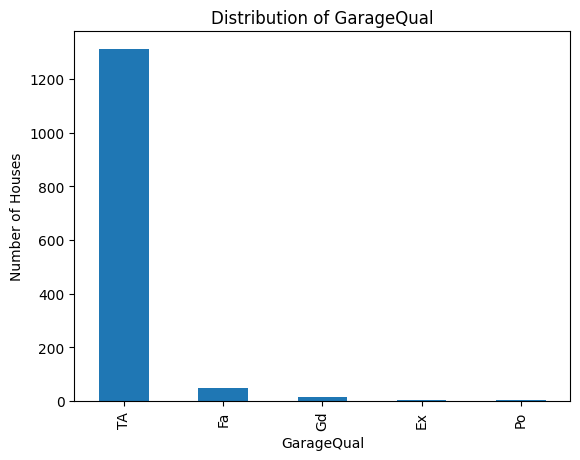

In [5]:
# Bar Plot 
def bar_plot(df, feature):
    df[feature].value_counts().sort_values(ascending=False).plot.bar()
    plt.xlabel(feature)
    plt.ylabel('Number of Houses')
    plt.title('Distribution of '+ feature)
    plt.show()

bar_plot(df, 'GarageQual')    

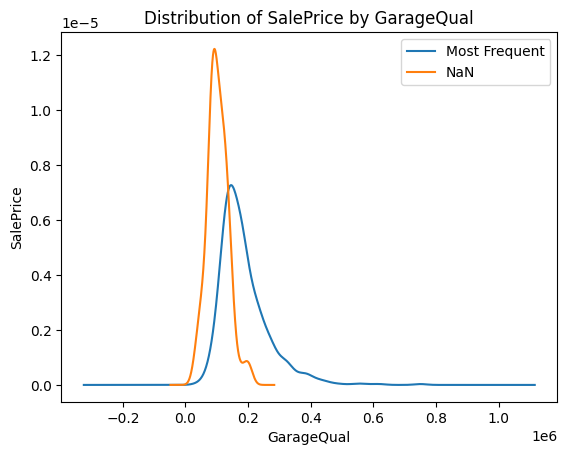

In [6]:
# Distribution Plot 
def dist_plot(df ,feature, most_frq, target_name):
    
    fig, ax = plt.subplots()
    df[df[feature]==most_frq][target_name].plot(kind='kde', ax=ax)
    df[df[feature].isnull()][target_name].plot(kind='kde', ax=ax)
    
    plt.xlabel(feature)
    plt.ylabel(target_name)
    plt.title(f'Distribution of {target_name } by {feature}')
    plt.legend(['Most Frequent', 'NaN'])
    plt.show()
    

dist_plot(df , 'GarageQual' , df['GarageQual'].mode()[0] , 'SalePrice')


/var/folders/t6/83ml_h093hb2vy010z1bgz_m0000gn/T/ipykernel_36176/1114518033.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['GarageQual'].fillna('TA', inplace=True)


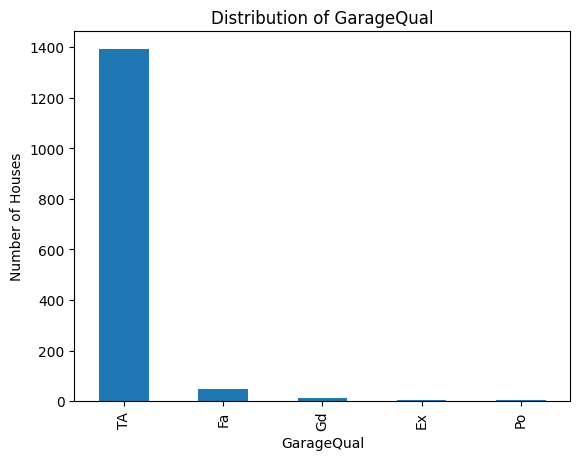

In [7]:
# FIll Missing Values with Mode
temp = df[df['GarageQual'] =='TA']['SalePrice']
df['GarageQual'].fillna('TA', inplace=True)

bar_plot(df , 'GarageQual')      

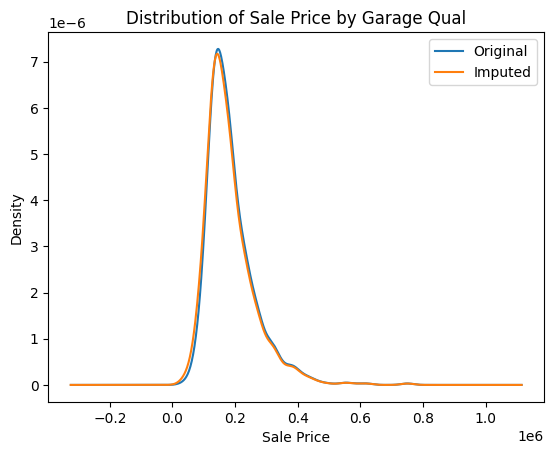

In [8]:
# After Imputation
fig, ax = plt.subplots()

temp.plot(kind='kde', ax=ax)

df[df['GarageQual'] == 'TA']['SalePrice'].plot(kind='kde',ax=ax)

plt.xlabel('Sale Price')
plt.ylabel('Density')
plt.title('Distribution of Sale Price by Garage Qual')
plt.legend(['Original', 'Imputed'])
plt.show()

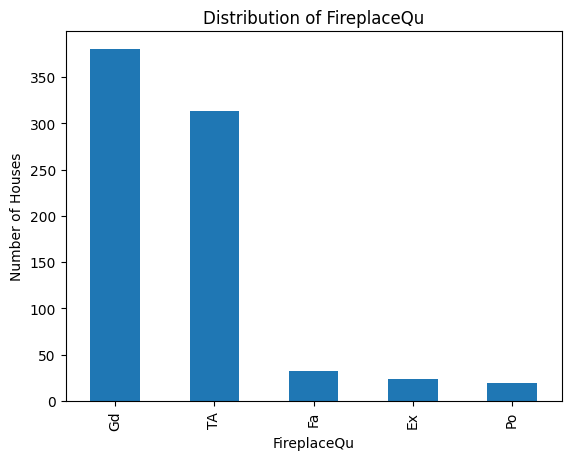

In [9]:
# For Next Feature
bar_plot(df, 'FireplaceQu')    

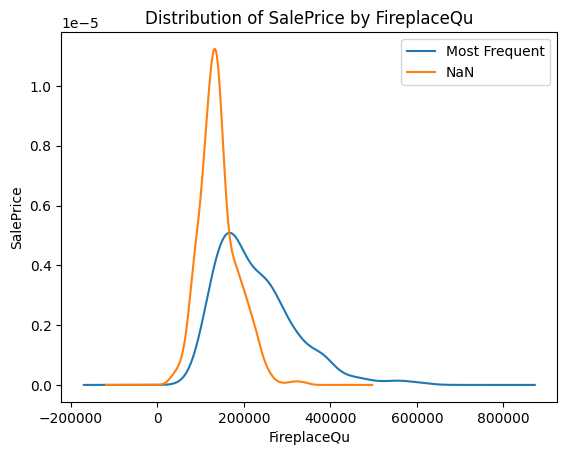

In [10]:
# Distribution of Sale Price by Fireplace Qu
dist_plot(df , 'FireplaceQu' , df['FireplaceQu'].mode()[0] , 'SalePrice')

/var/folders/t6/83ml_h093hb2vy010z1bgz_m0000gn/T/ipykernel_36176/3547793885.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['FireplaceQu'].fillna('Gd', inplace=True)


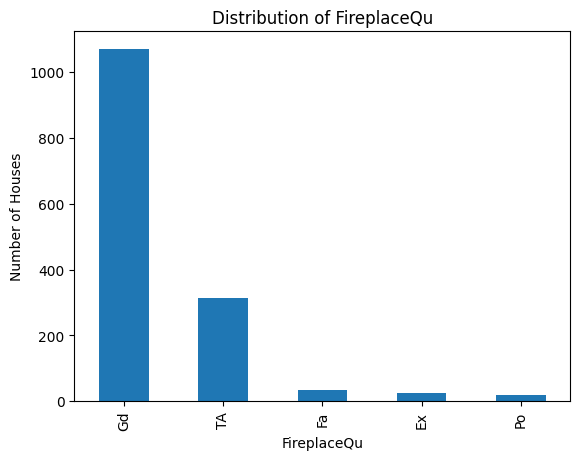

In [11]:
# FIll Missing Values with Mode
temp1 = df[df['FireplaceQu'] =='Gd']['SalePrice']
df['FireplaceQu'].fillna('Gd', inplace=True)

bar_plot(df , 'FireplaceQu')  

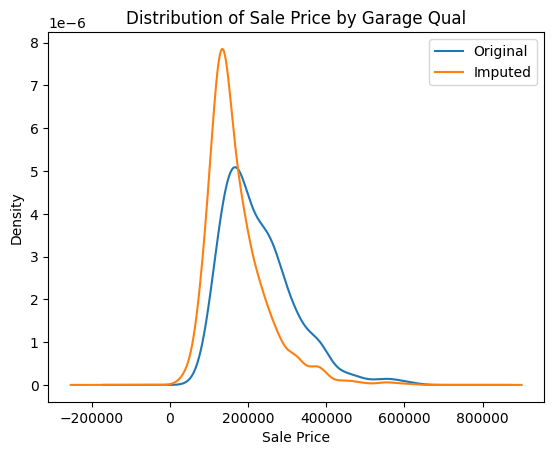

In [12]:
fig, ax = plt.subplots()

temp1.plot(kind='kde', ax=ax)

df[df['FireplaceQu'] == 'Gd']['SalePrice'].plot(kind='kde',ax=ax)

plt.xlabel('Sale Price')
plt.ylabel('Density')
plt.title('Distribution of Sale Price by Garage Qual')
plt.legend(['Original', 'Imputed'])
plt.show()

### 2. Using Sklearn

In [13]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['SalePrice'])
y = df['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('Shape of X_train:', X_train.shape)
print('Shape of X_test:', X_test.shape)

Shape of X_train: (1168, 2)
Shape of X_test: (292, 2)


In [14]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='most_frequent')
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

In [15]:
imputer.statistics_

array(['Gd', 'TA'], dtype=object)

## B. "Missing" / Constant Label Imputation


In [18]:
# Importing DataSet
df = pd.read_csv("../../data/House.csv", usecols=['GarageQual', 'FireplaceQu', 'SalePrice'])
df.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [19]:
# Percentage Missing Values
df.isnull().mean()*100

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

In [20]:
from sklearn.model_selection import train_test_split
X = df.drop(columns=['SalePrice'])
y = df['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('Shape of X_train:', X_train.shape)
print('Shape of X_test:', X_test.shape)

Shape of X_train: (1168, 2)
Shape of X_test: (292, 2)


In [21]:
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

imputer1 = SimpleImputer(strategy='constant', fill_value='Missing')
imputer2 = SimpleImputer(strategy='constant', fill_value='Not Disclosed')

trf = ColumnTransformer([
    ('FireplaceQu_impute', imputer1, ['FireplaceQu']),
    ('GarageQual_impute', imputer2, ['GarageQual'])
],remainder='passthrough')

trf.fit(X_train)

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('FireplaceQu_impute', ...), ('GarageQual_impute', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``tra

In [22]:
X_train_imputed = trf.transform(X_train)
X_test_imputed = trf.transform(X_test)


# Display the transformed data
X_train_imputed = pd.DataFrame(X_train_imputed, columns=X_train.columns)
X_test_imputed = pd.DataFrame(X_test_imputed, columns=X_test.columns)
X_train_imputed.sample(5)

,FireplaceQu,GarageQual
784,Missing,TA
909,Gd,TA
484,Missing,Not Disclosed
102,Gd,TA
271,Gd,TA


<Axes: xlabel='FireplaceQu'>

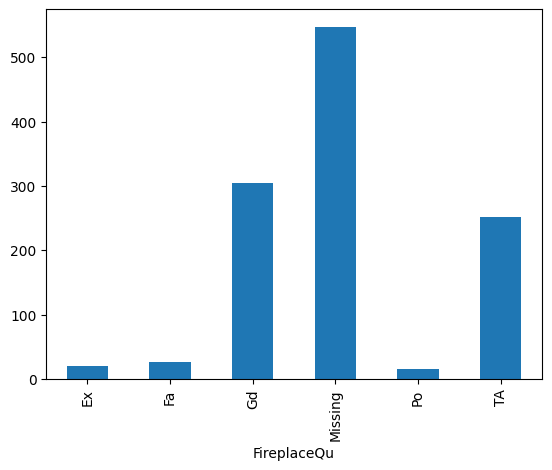

In [23]:
X_train_imputed['FireplaceQu'].value_counts().sort_index().plot(kind='bar')
# Not Recommended to use this imputation strategy for categorical variables. It may lead to incorrect results and should be used with caution.

<Axes: xlabel='GarageQual'>

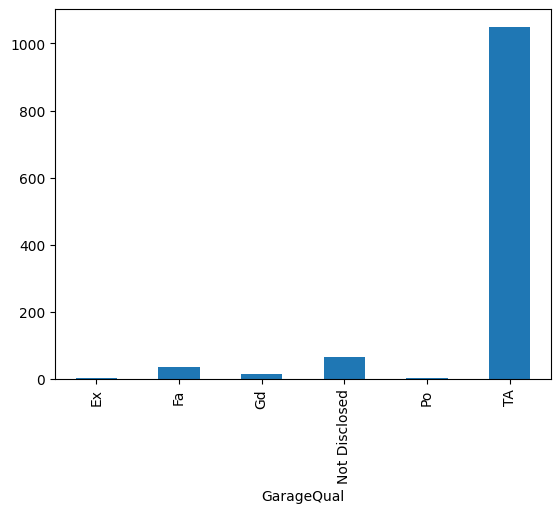

In [24]:
X_train_imputed['GarageQual'].value_counts().sort_index().plot(kind='bar')
# This imputation is acceptable as it does not change the distribution of the values.

## C. Random Sample Imputation (Categorical variant)

In [25]:
known_values_f1 = X_train['FireplaceQu'].dropna()
known_values_f2 = X_train['GarageQual'].dropna()

missing_count_f1 = X_train['FireplaceQu'].isnull().sum()
missing_count_f2 = X_train['GarageQual'].isnull().sum()

X_train.loc[X_train['FireplaceQu'].isnull(), 'FireplaceQu' ] = known_values_f1.sample(missing_count_f1, random_state=42, replace=True).values
X_train.loc[X_train['GarageQual'].isnull(), 'GarageQual' ] = known_values_f2.sample(missing_count_f2, random_state=42, replace=True).values



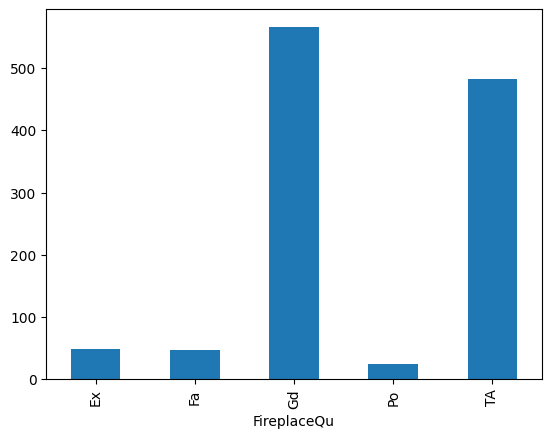

In [26]:
X_train['FireplaceQu'].value_counts().sort_index().plot(kind='bar')
plt.show()

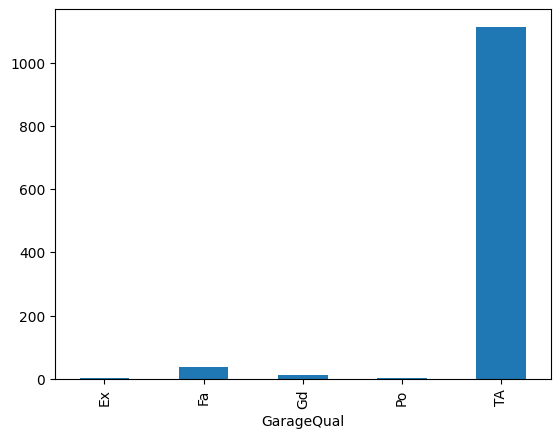

In [27]:
X_train['GarageQual'].value_counts().sort_index().plot(kind='bar')
plt.show()